# Comprehensive EDA, Training, and Experiments Notebook

This notebook provides a complete workflow for:
- Exploratory Data Analysis (EDA)
- Data Preprocessing and Feature Engineering
- Model Training and Evaluation
- Hyperparameter Tuning
- Experiment Tracking and Comparison

**Note:** Update the dataset path and target variable according to your project requirements.

## 1. Import Required Libraries

Import all necessary libraries for data analysis, visualization, and machine learning modeling.

In [1]:
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)

# Experiment Tracking
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore Dataset

Load the dataset and display basic information about its structure and content.

In [2]:
# Load the dataset
# TODO: Update the file path according to your dataset location
dataset_path = 'F:\\finalYearProject\\project_code\\inputs\\customers.csv'  # Change this to your dataset path

try:
    df = pd.read_csv(dataset_path)
    print(f"✓ Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print(f"✗ File not found: {dataset_path}")
    print("Creating sample dataset for demonstration...")
    # Create a sample dataset for demonstration
    np.random.seed(42)
    df = pd.DataFrame({
        'Age': np.random.randint(18, 80, 1000),
        'Income': np.random.randint(20000, 150000, 1000),
        'CreditScore': np.random.randint(300, 850, 1000),
        'LoanAmount': np.random.randint(5000, 500000, 1000),
        'EmploymentYears': np.random.randint(0, 40, 1000),
        'MaritalStatus': np.random.choice(['Single', 'Married', 'Divorced'], 1000),
        'Education': np.random.choice(['HS', 'Bachelor', 'Master'], 1000),
        'LoanApproved': np.random.choice([0, 1], 1000)
    })
    print("✓ Sample dataset created!")
    print(f"Dataset shape: {df.shape}")

# Display basic information
print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)
print("\nFirst few rows:")
print(df.head(10))

print("\n" + "-"*80)
print("Dataset Info:")
print("-"*80)
df.info()

print("\n" + "-"*80)
print("Statistical Summary:")
print("-"*80)
print(df.describe())

print("\n" + "-"*80)
print("Data Types:")
print("-"*80)
print(df.dtypes)

print("\n" + "-"*80)
print("Missing Values:")
print("-"*80)
missing_data = df.isnull().sum()
if missing_data.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing_data[missing_data > 0])

✓ Dataset loaded successfully!
Dataset shape: (3000, 6)

DATASET OVERVIEW

First few rows:
   customer_id signup_date      plan  monthly_fee  recency_days  churn
0            1  2023-02-05   premium         40.0           108      0
1            2  2021-09-06     basic         10.0           165      1
2            3  2023-05-14     basic         10.0           132      0
3            4  2021-12-13     basic         10.0           111      0
4            5  2021-08-12  standard         20.0            15      0
5            6  2023-05-24     basic         10.0            14      0
6            7  2022-12-05   premium         40.0           127      1
7            8  2023-01-11     basic         10.0           115      1
8            9  2023-12-19  standard         20.0           168      1
9           10  2022-03-05  standard         20.0            10      0

--------------------------------------------------------------------------------
Dataset Info:
--------------------------------

## 3. Data Preprocessing and Cleaning

Handle missing values, duplicates, outliers, and perform necessary data type conversions.

In [3]:
print("="*80)
print("DATA PREPROCESSING AND CLEANING")
print("="*80)

# Create a copy for preprocessing
df_clean = df.copy()

# 1. Handle missing values
print("\n1. Handling Missing Values:")
print("-"*80)
missing_cols = df_clean.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

if len(missing_cols) > 0:
    print(f"Found missing values in: {list(missing_cols.index)}")
    # For numerical columns: fill with mean
    # For categorical columns: fill with mode
    for col in missing_cols.index:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
            print(f"  ✓ Filled {col} with mean value")
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"  ✓ Filled {col} with mode value")
else:
    print("✓ No missing values to handle")

# 2. Remove duplicates
print("\n2. Removing Duplicates:")
print("-"*80)
duplicates_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = duplicates_before - len(df_clean)
print(f"✓ Removed {duplicates_removed} duplicate rows")
print(f"  Dataset shape after removing duplicates: {df_clean.shape}")

# 3. Identify and handle outliers using IQR method
print("\n3. Detecting and Handling Outliers (IQR Method):")
print("-"*80)
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

outlier_indices = set()
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"  {col}: Found {len(outliers)} outliers")
        outlier_indices.update(outliers.index)

print(f"✓ Total outlier rows detected: {len(outlier_indices)}")
print(f"  (Note: Outliers are kept for now; remove if needed for your use case)")

# Display cleaned dataset info
print("\n4. Cleaned Dataset Summary:")
print("-"*80)
print(f"Final dataset shape: {df_clean.shape}")
print(f"No missing values: {df_clean.isnull().sum().sum() == 0}")
print(f"Duplicates removed: {duplicates_removed}")

DATA PREPROCESSING AND CLEANING

1. Handling Missing Values:
--------------------------------------------------------------------------------
✓ No missing values to handle

2. Removing Duplicates:
--------------------------------------------------------------------------------
✓ Removed 0 duplicate rows
  Dataset shape after removing duplicates: (3000, 6)

3. Detecting and Handling Outliers (IQR Method):
--------------------------------------------------------------------------------
  monthly_fee: Found 440 outliers
✓ Total outlier rows detected: 440
  (Note: Outliers are kept for now; remove if needed for your use case)

4. Cleaned Dataset Summary:
--------------------------------------------------------------------------------
Final dataset shape: (3000, 6)
No missing values: True
Duplicates removed: 0


## 4. Exploratory Data Analysis (EDA)

Generate summary statistics and create visualizations to understand data patterns and relationships.

EXPLORATORY DATA ANALYSIS (EDA)

Target Variable: churn
Numerical Columns: ['customer_id', 'monthly_fee', 'recency_days', 'churn']
Categorical Columns: ['signup_date', 'plan']

1. STATISTICAL SUMMARY

Numerical Columns Statistics:
               count         mean         std   min     25%     50%      75%  \
customer_id   3000.0  1500.500000  866.169729   1.0  750.75  1500.5  2250.25   
monthly_fee   3000.0    17.966667   10.209487  10.0   10.00    20.0    20.00   
recency_days  3000.0    98.077000   57.692124   0.0   48.00    99.0   148.00   
churn         3000.0     0.275333    0.446757   0.0    0.00     0.0     1.00   

                 max  
customer_id   3000.0  
monthly_fee     40.0  
recency_days   199.0  
churn            1.0  


Categorical Columns Value Counts:

signup_date:
signup_date
2022-08-11    8
2021-06-29    8
2022-01-15    8
2023-02-07    8
2023-04-05    8
             ..
2022-12-21    1
2021-03-24    1
2021-08-29    1
2023-01-08    1
2022-11-02    1
Name: count, Le

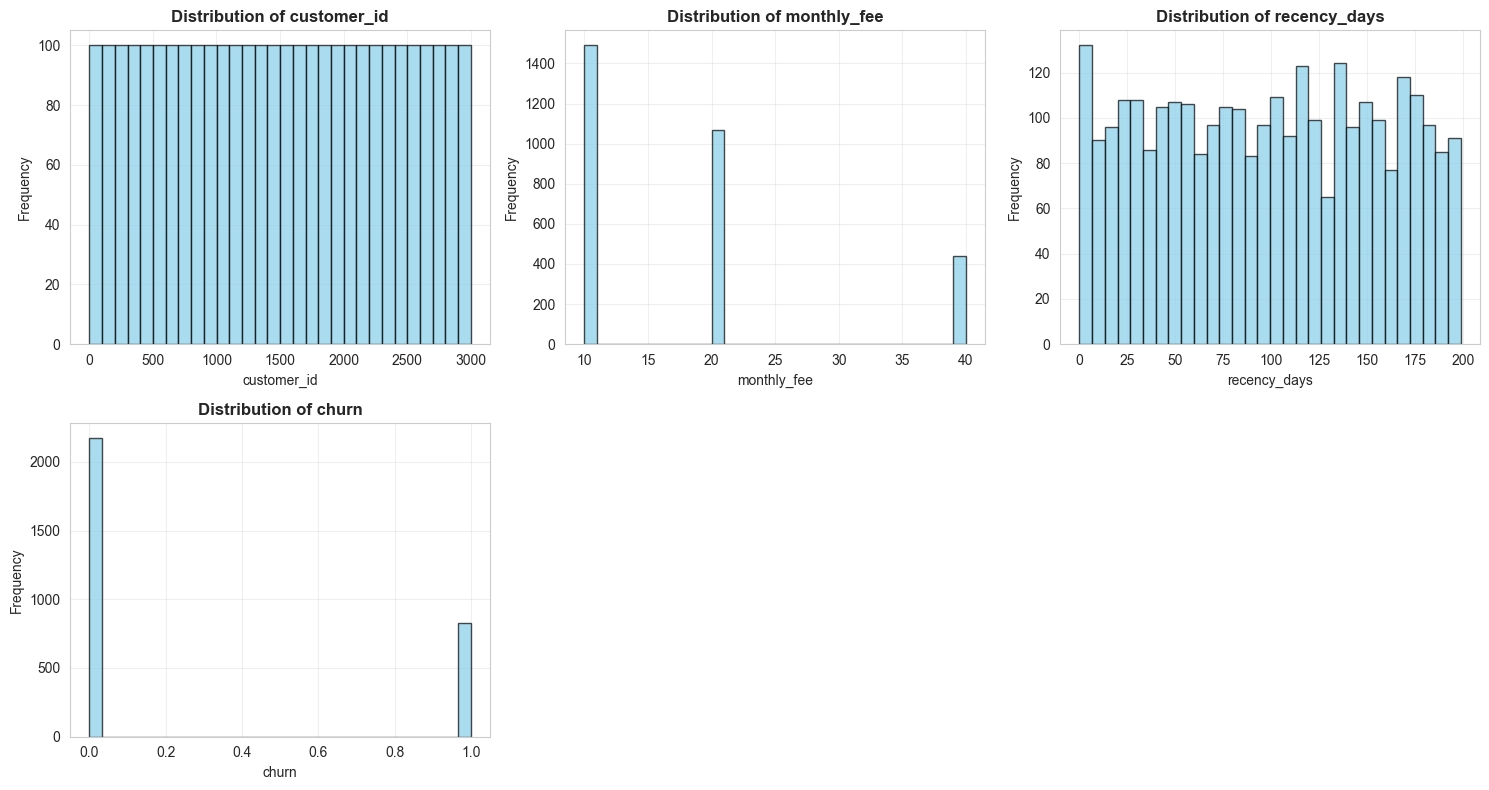

✓ Distribution plots saved as '01_distributions.png'

3. OUTLIER DETECTION (Box Plots)


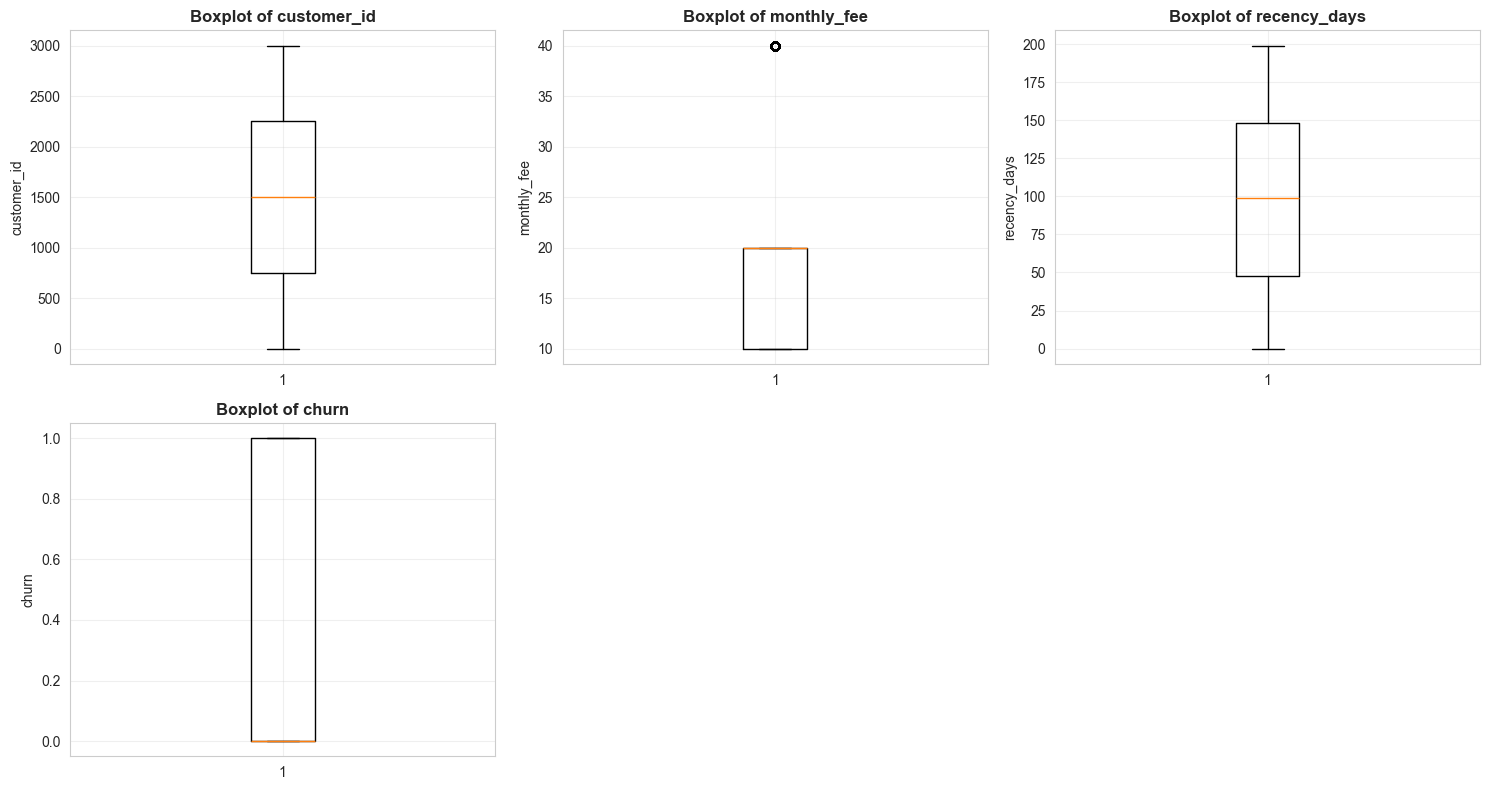

✓ Boxplot visualizations saved as '02_boxplots.png'

4. CORRELATION ANALYSIS

Correlation Matrix:
              customer_id  monthly_fee  recency_days     churn
customer_id      1.000000    -0.026719      0.018829  0.003409
monthly_fee     -0.026719     1.000000     -0.050480 -0.040242
recency_days     0.018829    -0.050480      1.000000  0.289977
churn            0.003409    -0.040242      0.289977  1.000000


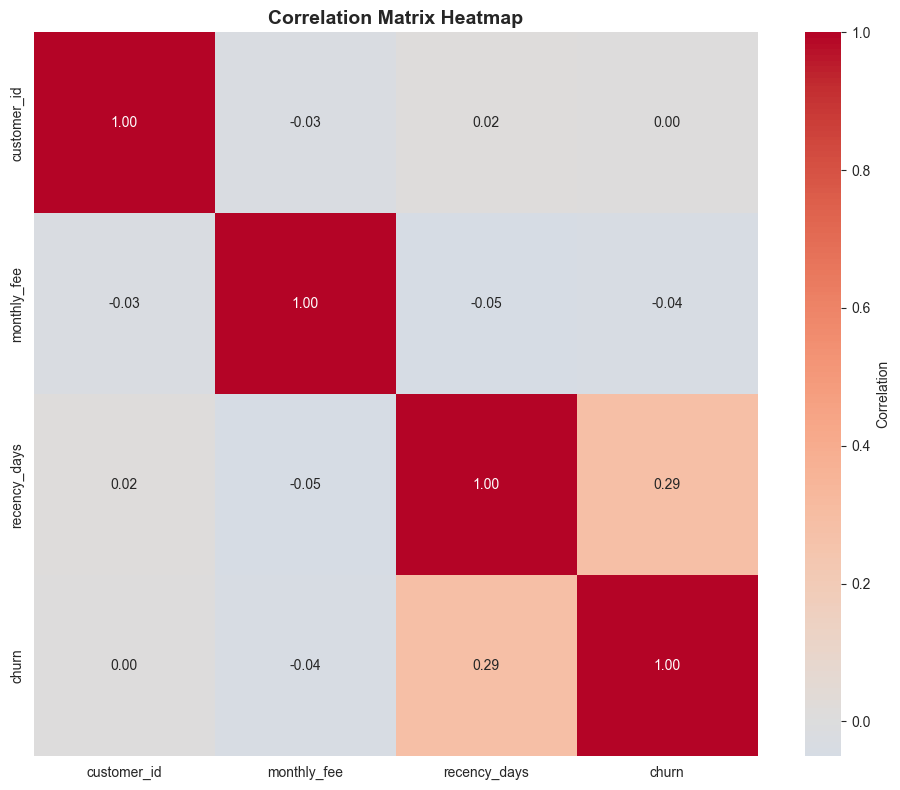

✓ Correlation heatmap saved as '03_correlation_heatmap.png'


Top 10 Highest Correlations (excluding diagonal):
  recency_days <-> churn: 0.290
  monthly_fee <-> recency_days: -0.050
  monthly_fee <-> churn: -0.040
  customer_id <-> monthly_fee: -0.027
  customer_id <-> recency_days: 0.019
  customer_id <-> churn: 0.003

5. TARGET VARIABLE ANALYSIS: churn

Target Variable Distribution:
churn
0    2174
1     826
Name: count, dtype: int64

Target Variable Proportions:
churn
0    0.724667
1    0.275333
Name: proportion, dtype: float64


In [4]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Separate numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Target variable (update according to your dataset)
target_col = None
if 'LoanApproved' in df_clean.columns:
    target_col = 'LoanApproved'
elif 'target' in df_clean.columns:
    target_col = 'target'
else:
    target_col = numerical_cols[-1] if numerical_cols else categorical_cols[-1]

print(f"\nTarget Variable: {target_col}")
print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

# 1. Statistical Summary
print("\n" + "="*80)
print("1. STATISTICAL SUMMARY")
print("="*80)
print("\nNumerical Columns Statistics:")
print(df_clean[numerical_cols].describe().T)

print("\n\nCategorical Columns Value Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())

# 2. Distribution plots for numerical features
print("\n" + "="*80)
print("2. DISTRIBUTION ANALYSIS")
print("="*80)

fig, axes = plt.subplots(
    nrows=(len(numerical_cols) + 2) // 3,
    ncols=3,
    figsize=(15, (len(numerical_cols) + 2) // 3 * 4)
)
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_clean[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide empty subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('01_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Distribution plots saved as '01_distributions.png'")

# 3. Box plots for outlier detection
print("\n" + "="*80)
print("3. OUTLIER DETECTION (Box Plots)")
print("="*80)

fig, axes = plt.subplots(
    nrows=(len(numerical_cols) + 2) // 3,
    ncols=3,
    figsize=(15, (len(numerical_cols) + 2) // 3 * 4)
)
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df_clean[col])
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('02_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Boxplot visualizations saved as '02_boxplots.png'")

# 4. Correlation Analysis
print("\n" + "="*80)
print("4. CORRELATION ANALYSIS")
print("="*80)

if len(numerical_cols) > 1:
    correlation_matrix = df_clean[numerical_cols].corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Create correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, cbar_kws={'label': 'Correlation'}, square=True)
    plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Correlation heatmap saved as '03_correlation_heatmap.png'")
    
    # Find highest correlations
    print("\n\nTop 10 Highest Correlations (excluding diagonal):")
    corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    for col1, col2, corr in corr_pairs[:10]:
        print(f"  {col1} <-> {col2}: {corr:.3f}")

# 5. Relationship with target variable
if target_col and target_col in df_clean.columns:
    print("\n" + "="*80)
    print(f"5. TARGET VARIABLE ANALYSIS: {target_col}")
    print("="*80)
    print(f"\nTarget Variable Distribution:")
    print(df_clean[target_col].value_counts())
    print(f"\nTarget Variable Proportions:")
    print(df_clean[target_col].value_counts(normalize=True))

## 5. Feature Engineering

Create new features, encode categorical variables, scale numerical features, and select relevant features.

In [5]:
print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

df_features = df_clean.copy()

# 1. Create new features (customize based on your data)
print("\n1. Creating New Features:")
print("-"*80)

# Example: Create interaction features or derived features
for col1 in numerical_cols:
    for col2 in numerical_cols:
        if col1 < col2:  # Avoid duplicates
            interaction_name = f'{col1}_x_{col2}'
            df_features[interaction_name] = df_features[col1] * df_features[col2]
            print(f"  ✓ Created feature: {interaction_name}")

# Example: Create ratio features
if 'Income' in df_features.columns and 'LoanAmount' in df_features.columns:
    df_features['LoanToIncomeRatio'] = df_features['LoanAmount'] / (df_features['Income'] + 1)
    print(f"  ✓ Created feature: LoanToIncomeRatio")

print(f"\n✓ New features created. Total features now: {df_features.shape[1]}")

# 2. Encode Categorical Variables
print("\n2. Encoding Categorical Variables:")
print("-"*80)

df_encoded = df_features.copy()

# Label encoding for ordinal categorical variables
ordinal_cols = []  # Add ordinal columns if any
for col in ordinal_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        print(f"  ✓ Label encoded: {col}")

# One-Hot encoding for nominal categorical variables
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]
if nominal_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)
    print(f"  ✓ One-hot encoded: {nominal_cols}")

print(f"\n✓ Encoding complete. Final feature count: {df_encoded.shape[1]}")

# 3. Feature Scaling
print("\n3. Feature Scaling:")
print("-"*80)

# Separate features and target
if target_col in df_encoded.columns:
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]
else:
    X = df_encoded
    y = None

# Scale numerical features
scaler = StandardScaler()
numerical_feature_cols = X.select_dtypes(include=[np.number]).columns
X_scaled = X.copy()
X_scaled[numerical_feature_cols] = scaler.fit_transform(X[numerical_feature_cols])

print(f"  ✓ Scaled {len(numerical_feature_cols)} numerical features")
print(f"  Features shape: {X_scaled.shape}")

# 4. Feature Selection (based on correlation with target)
print("\n4. Feature Selection:")
print("-"*80)

if y is not None:
    feature_importance = pd.DataFrame({
        'feature': X_scaled.columns,
        'correlation': [X_scaled[col].corr(y) for col in X_scaled.columns]
    })
    feature_importance['abs_correlation'] = feature_importance['correlation'].abs()
    feature_importance = feature_importance.sort_values('abs_correlation', ascending=False)
    
    print("\nTop 20 Features (by correlation with target):")
    print(feature_importance.head(20).to_string(index=False))
    
    # Select top features (you can adjust the threshold)
    top_k = min(20, len(feature_importance))
    selected_features = feature_importance.head(top_k)['feature'].tolist()
    X_selected = X_scaled[selected_features]
    
    print(f"\n✓ Selected {len(selected_features)} most important features")
else:
    X_selected = X_scaled
    selected_features = X_scaled.columns.tolist()

print(f"\nFinal feature set shape: {X_selected.shape}")

FEATURE ENGINEERING

1. Creating New Features:
--------------------------------------------------------------------------------
  ✓ Created feature: customer_id_x_monthly_fee
  ✓ Created feature: customer_id_x_recency_days
  ✓ Created feature: monthly_fee_x_recency_days
  ✓ Created feature: churn_x_customer_id
  ✓ Created feature: churn_x_monthly_fee
  ✓ Created feature: churn_x_recency_days

✓ New features created. Total features now: 12

2. Encoding Categorical Variables:
--------------------------------------------------------------------------------
  ✓ One-hot encoded: ['signup_date', 'plan']

✓ Encoding complete. Final feature count: 1035

3. Feature Scaling:
--------------------------------------------------------------------------------
  ✓ Scaled 9 numerical features
  Features shape: (3000, 1034)

4. Feature Selection:
--------------------------------------------------------------------------------

Top 20 Features (by correlation with target):
                   feature  cor

## 6. Data Splitting

Split the dataset into training, validation, and testing sets.

In [6]:
print("="*80)
print("DATA SPLITTING")
print("="*80)

if y is None:
    print("\n✗ Target variable not found. Please update target_col variable.")
    print("Using last numerical column as target for demonstration.")
    y = X_selected.iloc[:, -1]
    X_selected = X_selected.iloc[:, :-1]

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y if y.dtype=='int64' else None
)

# Second split: 75% train (of temp), 25% val (of temp) → 60% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp if y_temp.dtype=='int64' else None
)

print("\nData Split Distribution:")
print("-"*80)
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X_selected)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_selected)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_selected)*100:.1f}%)")
print(f"Total:          {len(X_selected)} samples")

print("\n" + "-"*80)
print("Feature Dimensions:")
print("-"*80)
print(f"Features: {X_train.shape[1]}")
print(f"X_train shape:  {X_train.shape}")
print(f"X_val shape:    {X_val.shape}")
print(f"X_test shape:   {X_test.shape}")

print("\n" + "-"*80)
print("Target Distribution:")
print("-"*80)
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nValidation set target distribution:")
print(y_val.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

# Verify no data leakage
print("\n" + "-"*80)
print("Data Integrity Check:")
print("-"*80)
print(f"✓ No overlapping indices between train and val: {len(set(X_train.index) & set(X_val.index)) == 0}")
print(f"✓ No overlapping indices between train and test: {len(set(X_train.index) & set(X_test.index)) == 0}")
print(f"✓ No overlapping indices between val and test: {len(set(X_val.index) & set(X_test.index)) == 0}")

DATA SPLITTING

Data Split Distribution:
--------------------------------------------------------------------------------
Training set:   1800 samples (60.0%)
Validation set: 600 samples (20.0%)
Test set:       600 samples (20.0%)
Total:          3000 samples

--------------------------------------------------------------------------------
Feature Dimensions:
--------------------------------------------------------------------------------
Features: 20
X_train shape:  (1800, 20)
X_val shape:    (600, 20)
X_test shape:   (600, 20)

--------------------------------------------------------------------------------
Target Distribution:
--------------------------------------------------------------------------------

Training set target distribution:
churn
0    1304
1     496
Name: count, dtype: int64

Validation set target distribution:
churn
0    435
1    165
Name: count, dtype: int64

Test set target distribution:
churn
0    435
1    165
Name: count, dtype: int64

-------------------------

## 7. Model Selection and Initialization

Select appropriate machine learning algorithms and initialize models.

In [7]:
print("="*80)
print("MODEL SELECTION AND INITIALIZATION")
print("="*80)

# Determine task type (classification or regression)
task_type = 'classification' if y.dtype == 'int64' and len(y.unique()) <= 10 else 'regression'
print(f"\nDetected Task Type: {task_type.upper()}")
print(f"Number of classes/values: {len(y.unique())}")

# Initialize models based on task type
models = {}

if task_type == 'classification':
    print("\n" + "-"*80)
    print("Initializing Classification Models:")
    print("-"*80)
    
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(probability=True, random_state=42)
    }
    
    for model_name, model in models.items():
        print(f"  ✓ {model_name}: {type(model).__name__}")
    
    metrics_to_track = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    
else:
    print("\n" + "-"*80)
    print("Initializing Regression Models:")
    print("-"*80)
    
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting Regressor': GradientBoostingClassifier(n_estimators=100, random_state=42),
    }
    
    for model_name, model in models.items():
        print(f"  ✓ {model_name}: {type(model).__name__}")
    
    metrics_to_track = ['mse', 'rmse', 'mae', 'r2']

print(f"\nTotal models initialized: {len(models)}")
print(f"Metrics to track: {metrics_to_track}")

MODEL SELECTION AND INITIALIZATION

Detected Task Type: CLASSIFICATION
Number of classes/values: 2

--------------------------------------------------------------------------------
Initializing Classification Models:
--------------------------------------------------------------------------------
  ✓ Logistic Regression: LogisticRegression
  ✓ K-Nearest Neighbors: KNeighborsClassifier
  ✓ Random Forest: RandomForestClassifier
  ✓ Gradient Boosting: GradientBoostingClassifier
  ✓ SVM: SVC

Total models initialized: 5
Metrics to track: ['accuracy', 'precision', 'recall', 'f1', 'auc']


## 8. Model Training

Train the initialized models on the training dataset.

In [8]:
print("="*80)
print("MODEL TRAINING")
print("="*80)

trained_models = {}
training_history = {}

for model_name, model in models.items():
    print(f"\n{'-'*80}")
    print(f"Training: {model_name}")
    print(f"{'-'*80}")
    
    try:
        # Train the model
        model.fit(X_train, y_train)
        trained_models[model_name] = model
        
        # Calculate training metrics
        y_train_pred = model.predict(X_train)
        
        if task_type == 'classification':
            train_accuracy = accuracy_score(y_train, y_train_pred)
            print(f"  Training Accuracy: {train_accuracy:.4f}")
            
            # Cross-validation score
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
            print(f"  Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
            
            training_history[model_name] = {
                'train_accuracy': train_accuracy,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std()
            }
        else:
            train_mse = mean_squared_error(y_train, y_train_pred)
            train_rmse = np.sqrt(train_mse)
            train_mae = mean_absolute_error(y_train, y_train_pred)
            train_r2 = r2_score(y_train, y_train_pred)
            
            print(f"  Training MSE: {train_mse:.4f}")
            print(f"  Training RMSE: {train_rmse:.4f}")
            print(f"  Training MAE: {train_mae:.4f}")
            print(f"  Training R²: {train_r2:.4f}")
            
            training_history[model_name] = {
                'mse': train_mse,
                'rmse': train_rmse,
                'mae': train_mae,
                'r2': train_r2
            }
        
        print(f"  ✓ {model_name} trained successfully!")
        
    except Exception as e:
        print(f"  ✗ Error training {model_name}: {str(e)}")

print(f"\n{'='*80}")
print(f"✓ Successfully trained {len(trained_models)} models!")
print(f"{'='*80}")

MODEL TRAINING

--------------------------------------------------------------------------------
Training: Logistic Regression
--------------------------------------------------------------------------------
  Training Accuracy: 1.0000
  Cross-Validation Accuracy: 1.0000 (+/- 0.0000)
  ✓ Logistic Regression trained successfully!

--------------------------------------------------------------------------------
Training: K-Nearest Neighbors
--------------------------------------------------------------------------------
  Training Accuracy: 1.0000
  Cross-Validation Accuracy: 1.0000 (+/- 0.0000)
  ✓ K-Nearest Neighbors trained successfully!

--------------------------------------------------------------------------------
Training: Random Forest
--------------------------------------------------------------------------------
  Training Accuracy: 1.0000
  Cross-Validation Accuracy: 1.0000 (+/- 0.0000)
  ✓ Random Forest trained successfully!

------------------------------------------------

## 9. Model Evaluation

Evaluate model performance using appropriate metrics on validation and test sets.

In [9]:
print("="*80)
print("MODEL EVALUATION")
print("="*80)

evaluation_results = {}

for model_name, model in trained_models.items():
    print(f"\n{'-'*80}")
    print(f"Evaluating: {model_name}")
    print(f"{'-'*80}")
    
    # Validation set evaluation
    y_val_pred = model.predict(X_val)
    
    # Test set evaluation
    y_test_pred = model.predict(X_test)
    
    if task_type == 'classification':
        # Validation metrics
        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
        val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
        
        try:
            val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]) if len(y.unique()) == 2 else None
        except:
            val_auc = None
        
        # Test metrics
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
        
        try:
            test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if len(y.unique()) == 2 else None
        except:
            test_auc = None
        
        print(f"\n  VALIDATION SET:")
        print(f"    Accuracy:  {val_accuracy:.4f}")
        print(f"    Precision: {val_precision:.4f}")
        print(f"    Recall:    {val_recall:.4f}")
        print(f"    F1-Score:  {val_f1:.4f}")
        if val_auc: print(f"    AUC-ROC:   {val_auc:.4f}")
        
        print(f"\n  TEST SET:")
        print(f"    Accuracy:  {test_accuracy:.4f}")
        print(f"    Precision: {test_precision:.4f}")
        print(f"    Recall:    {test_recall:.4f}")
        print(f"    F1-Score:  {test_f1:.4f}")
        if test_auc: print(f"    AUC-ROC:   {test_auc:.4f}")
        
        evaluation_results[model_name] = {
            'val_accuracy': val_accuracy,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'test_auc': test_auc
        }
        
    else:
        # Validation metrics
        val_mse = mean_squared_error(y_val, y_val_pred)
        val_rmse = np.sqrt(val_mse)
        val_mae = mean_absolute_error(y_val, y_val_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        
        # Test metrics
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_rmse = np.sqrt(test_mse)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        print(f"\n  VALIDATION SET:")
        print(f"    MSE:  {val_mse:.4f}")
        print(f"    RMSE: {val_rmse:.4f}")
        print(f"    MAE:  {val_mae:.4f}")
        print(f"    R²:   {val_r2:.4f}")
        
        print(f"\n  TEST SET:")
        print(f"    MSE:  {test_mse:.4f}")
        print(f"    RMSE: {test_rmse:.4f}")
        print(f"    MAE:  {test_mae:.4f}")
        print(f"    R²:   {test_r2:.4f}")
        
        evaluation_results[model_name] = {
            'val_mse': val_mse,
            'val_rmse': val_rmse,
            'val_mae': val_mae,
            'val_r2': val_r2,
            'test_mse': test_mse,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'test_r2': test_r2
        }

print(f"\n{'='*80}")
print("✓ Evaluation Complete!")
print(f"{'='*80}")

MODEL EVALUATION

--------------------------------------------------------------------------------
Evaluating: Logistic Regression
--------------------------------------------------------------------------------

  VALIDATION SET:
    Accuracy:  1.0000
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
    AUC-ROC:   1.0000

  TEST SET:
    Accuracy:  1.0000
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
    AUC-ROC:   1.0000

--------------------------------------------------------------------------------
Evaluating: K-Nearest Neighbors
--------------------------------------------------------------------------------

  VALIDATION SET:
    Accuracy:  1.0000
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
    AUC-ROC:   1.0000

  TEST SET:
    Accuracy:  1.0000
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
    AUC-ROC:   1.0000

--------------------------------------------------------------------------------
Evaluat

## 10. Hyperparameter Tuning

Perform grid search or random search to find optimal hyperparameters.

In [10]:
print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

tuning_results = {}

# Define hyperparameter grids for different models
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
}

# Models to tune (skip SVM due to long computation time)
models_to_tune = ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest']

for model_name in models_to_tune:
    if model_name not in trained_models:
        continue
    
    print(f"\n{'-'*80}")
    print(f"Tuning: {model_name}")
    print(f"{'-'*80}")
    
    model = trained_models[model_name]
    param_grid = param_grids.get(model_name, {})
    
    if not param_grid:
        print(f"  No parameter grid defined for {model_name}")
        continue
    
    try:
        # Use GridSearchCV
        scoring = 'accuracy' if task_type == 'classification' else 'r2'
        
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=5,
            scoring=scoring,
            n_jobs=-1,
            verbose=0
        )
        
        print(f"  Searching over {len(param_grid)} hyperparameter combinations...")
        grid_search.fit(X_train, y_train)
        
        print(f"\n  Best Parameters:")
        for param, value in grid_search.best_params_.items():
            print(f"    {param}: {value}")
        
        print(f"\n  Best CV Score: {grid_search.best_score_:.4f}")
        
        # Evaluate best model
        best_model = grid_search.best_estimator_
        y_val_pred = best_model.predict(X_val)
        
        if task_type == 'classification':
            val_score = accuracy_score(y_val, y_val_pred)
            print(f"  Validation Score: {val_score:.4f}")
        else:
            val_score = r2_score(y_val, y_val_pred)
            print(f"  Validation R² Score: {val_score:.4f}")
        
        # Update trained models with best model
        trained_models[model_name] = best_model
        
        tuning_results[model_name] = {
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'val_score': val_score
        }
        
        print(f"  ✓ {model_name} tuned successfully!")
        
    except Exception as e:
        print(f"  ✗ Error tuning {model_name}: {str(e)}")

print(f"\n{'='*80}")
print("✓ Hyperparameter Tuning Complete!")
print(f"{'='*80}")

HYPERPARAMETER TUNING

--------------------------------------------------------------------------------
Tuning: Logistic Regression
--------------------------------------------------------------------------------
  Searching over 3 hyperparameter combinations...

  Best Parameters:
    C: 0.1
    penalty: l1
    solver: liblinear

  Best CV Score: 1.0000
  Validation Score: 1.0000
  ✓ Logistic Regression tuned successfully!

--------------------------------------------------------------------------------
Tuning: K-Nearest Neighbors
--------------------------------------------------------------------------------
  Searching over 3 hyperparameter combinations...

  Best Parameters:
    n_neighbors: 3
    p: 1
    weights: uniform

  Best CV Score: 1.0000
  Validation Score: 1.0000
  ✓ K-Nearest Neighbors tuned successfully!

--------------------------------------------------------------------------------
Tuning: Random Forest
--------------------------------------------------------------

## 11. Experiment Tracking and Comparison

Track different experiment runs, compare results across models, and document findings.

In [11]:
print("="*80)
print("EXPERIMENT TRACKING AND COMPARISON")
print("="*80)

# Create experiment summary
experiment_summary = []

for model_name, metrics in evaluation_results.items():
    experiment = {
        'Model': model_name,
        'Timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    if task_type == 'classification':
        experiment.update({
            'Val_Accuracy': metrics['val_accuracy'],
            'Val_F1': metrics['val_f1'],
            'Test_Accuracy': metrics['test_accuracy'],
            'Test_F1': metrics['test_f1'],
            'Test_Precision': metrics['test_precision'],
            'Test_Recall': metrics['test_recall']
        })
    else:
        experiment.update({
            'Val_RMSE': metrics['val_rmse'],
            'Val_R2': metrics['val_r2'],
            'Test_RMSE': metrics['test_rmse'],
            'Test_R2': metrics['test_r2'],
            'Test_MAE': metrics['test_mae']
        })
    
    # Add tuning info if available
    if model_name in tuning_results:
        experiment['Tuned'] = 'Yes'
        experiment['Best_CV_Score'] = tuning_results[model_name]['best_cv_score']
    else:
        experiment['Tuned'] = 'No'
    
    experiment_summary.append(experiment)

# Create comparison DataFrame
comparison_df = pd.DataFrame(experiment_summary)

print("\n" + "="*80)
print("EXPERIMENT COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))

# Save comparison results
comparison_df.to_csv('experiment_comparison.csv', index=False)
print("\n✓ Experiment comparison saved as 'experiment_comparison.csv'")

# Identify best model
if task_type == 'classification':
    best_model_idx = comparison_df['Test_Accuracy'].idxmax()
    best_metric = 'Test_Accuracy'
else:
    best_model_idx = comparison_df['Test_R2'].idxmax()
    best_metric = 'Test_R2'

best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_metric_value = comparison_df.loc[best_model_idx, best_metric]

print("\n" + "="*80)
print("BEST PERFORMING MODEL")
print("="*80)
print(f"Model: {best_model_name}")
print(f"{best_metric}: {best_metric_value:.4f}")
print(f"✓ Best model selected for deployment!")

# Create detailed experiment log
experiment_log = {
    'timestamp': datetime.now().isoformat(),
    'task_type': task_type,
    'dataset_shape': {
        'total': len(df_clean),
        'features': X_selected.shape[1]
    },
    'data_split': {
        'train': X_train.shape[0],
        'validation': X_val.shape[0],
        'test': X_test.shape[0]
    },
    'models': list(trained_models.keys()),
    'best_model': best_model_name,
    'best_score': float(best_metric_value),
    'evaluation_results': evaluation_results,
    'tuning_results': tuning_results
}

# Save experiment log
with open('experiment_log.json', 'w') as f:
    json.dump(experiment_log, f, indent=4)

print("\n✓ Experiment log saved as 'experiment_log.json'")

EXPERIMENT TRACKING AND COMPARISON

EXPERIMENT COMPARISON SUMMARY
              Model           Timestamp  Val_Accuracy  Val_F1  Test_Accuracy  Test_F1  Test_Precision  Test_Recall Tuned  Best_CV_Score
Logistic Regression 2025-12-08 23:23:50           1.0     1.0            1.0      1.0             1.0          1.0   Yes            1.0
K-Nearest Neighbors 2025-12-08 23:23:50           1.0     1.0            1.0      1.0             1.0          1.0   Yes            1.0
      Random Forest 2025-12-08 23:23:50           1.0     1.0            1.0      1.0             1.0          1.0   Yes            1.0
  Gradient Boosting 2025-12-08 23:23:50           1.0     1.0            1.0      1.0             1.0          1.0    No            NaN
                SVM 2025-12-08 23:23:50           1.0     1.0            1.0      1.0             1.0          1.0    No            NaN

✓ Experiment comparison saved as 'experiment_comparison.csv'

BEST PERFORMING MODEL
Model: Logistic Regression
Test_A

## 12. Results Visualization

Create comprehensive visualizations including confusion matrices, ROC curves, feature importance, and performance comparisons.

RESULTS VISUALIZATION

1. Creating Model Performance Comparison Chart...
--------------------------------------------------------------------------------


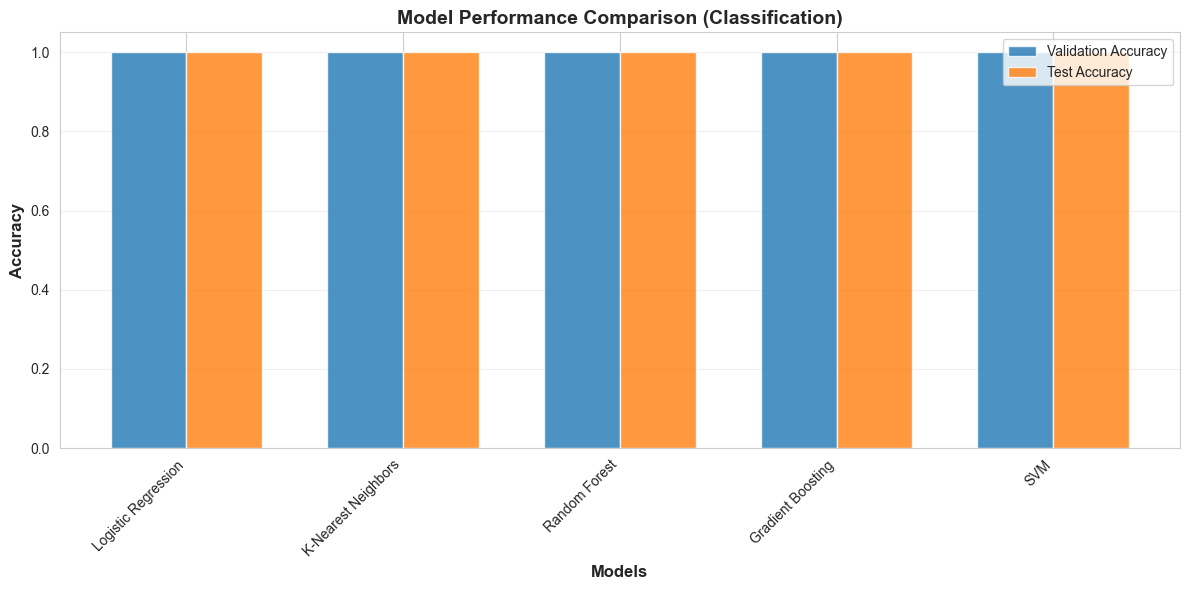

✓ Model comparison chart saved as '04_model_comparison.png'

2. Creating Confusion Matrices...
--------------------------------------------------------------------------------


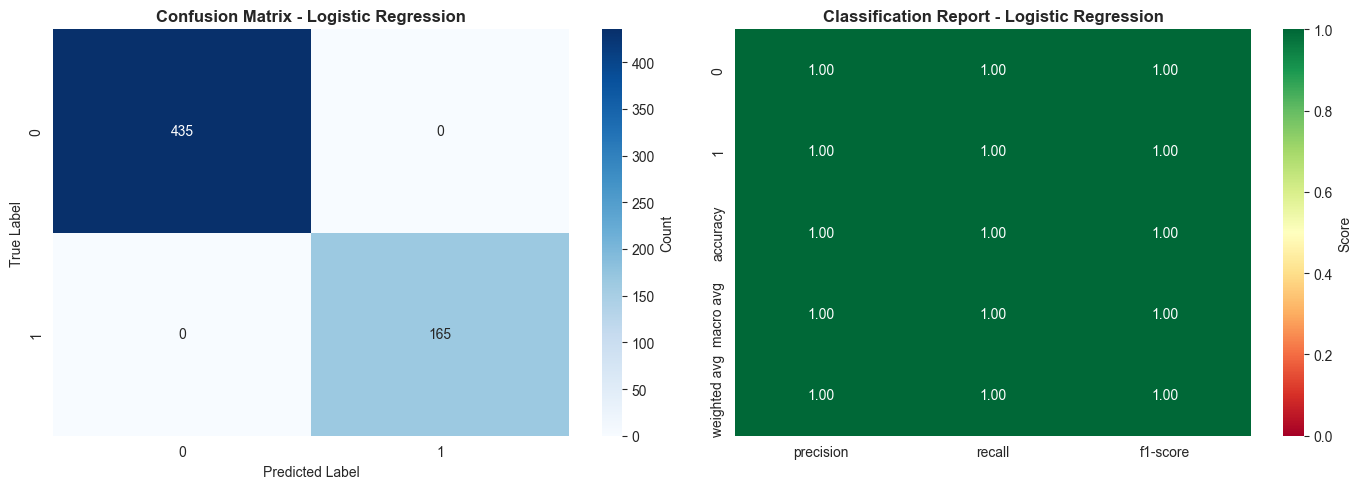

✓ Confusion matrices saved as '05_confusion_matrix.png'

3. Creating ROC Curves...
--------------------------------------------------------------------------------


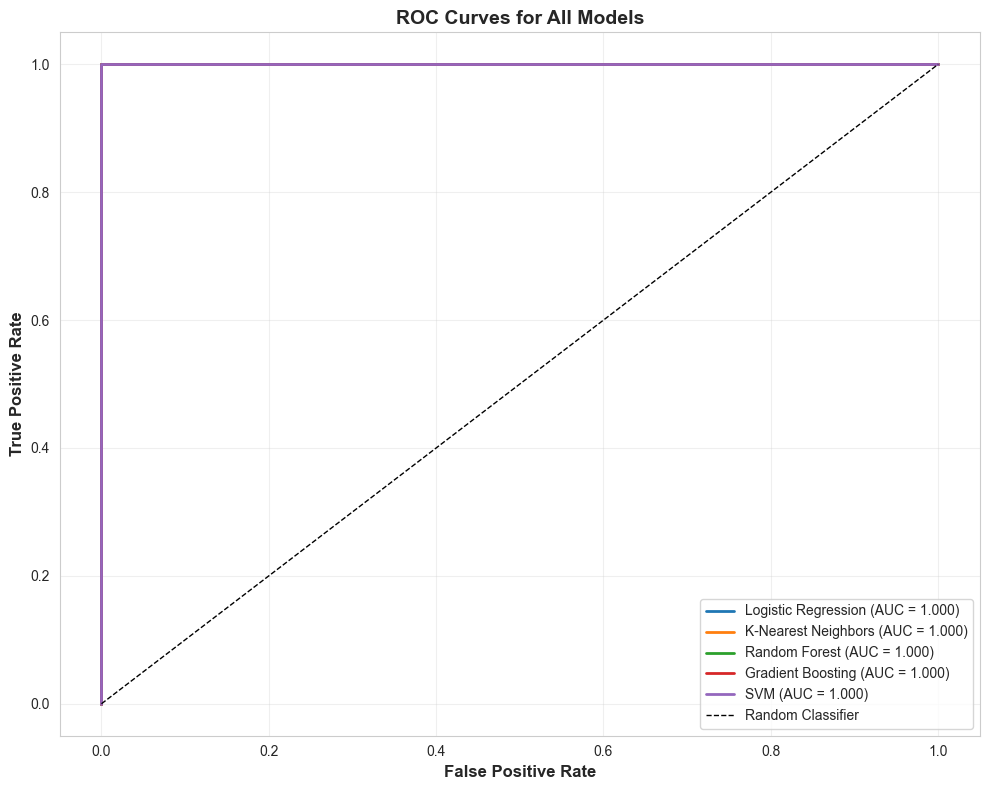

✓ ROC curves saved as '06_roc_curves.png'

4. Creating Feature Importance Plots...
--------------------------------------------------------------------------------


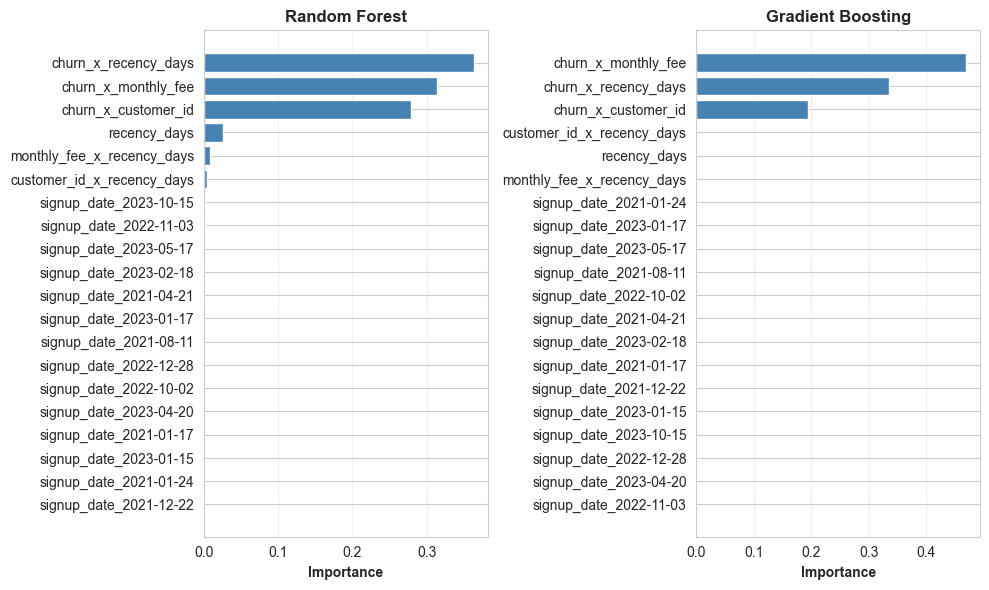

✓ Feature importance plots saved as '07_feature_importance.png'

✓ All Visualizations Complete!


In [12]:
print("="*80)
print("RESULTS VISUALIZATION")
print("="*80)

# 1. Model Performance Comparison
print("\n1. Creating Model Performance Comparison Chart...")
print("-"*80)

fig, ax = plt.subplots(figsize=(12, 6))

if task_type == 'classification':
    x = np.arange(len(comparison_df))
    width = 0.35
    
    val_scores = comparison_df['Val_Accuracy'].values
    test_scores = comparison_df['Test_Accuracy'].values
    
    bars1 = ax.bar(x - width/2, val_scores, width, label='Validation Accuracy', alpha=0.8)
    bars2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy', alpha=0.8)
    
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison (Classification)', fontsize=14, fontweight='bold')
    
else:
    x = np.arange(len(comparison_df))
    width = 0.35
    
    val_scores = comparison_df['Val_R2'].values
    test_scores = comparison_df['Test_R2'].values
    
    bars1 = ax.bar(x - width/2, val_scores, width, label='Validation R²', alpha=0.8)
    bars2 = ax.bar(x + width/2, test_scores, width, label='Test R²', alpha=0.8)
    
    ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison (Regression)', fontsize=14, fontweight='bold')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Model comparison chart saved as '04_model_comparison.png'")

# 2. Confusion Matrix for best Classification Model
if task_type == 'classification':
    print("\n2. Creating Confusion Matrices...")
    print("-"*80)
    
    best_model = trained_models[best_model_name]
    y_pred = best_model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=10)
    axes[0].set_xlabel('Predicted Label', fontsize=10)
    
    # Classification report heatmap
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).iloc[:-1, :].T
    
    sns.heatmap(report_df, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], 
                cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
    axes[1].set_title(f'Classification Report - {best_model_name}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('05_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Confusion matrices saved as '05_confusion_matrix.png'")
    
    # 3. ROC Curve for binary classification
    if len(y.unique()) == 2:
        print("\n3. Creating ROC Curves...")
        print("-"*80)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        for model_name, model in trained_models.items():
            try:
                y_pred_proba = model.predict_proba(X_test)[:, 1]
                fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2)
            except:
                pass
        
        ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
        ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        ax.set_title('ROC Curves for All Models', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('06_roc_curves.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ ROC curves saved as '06_roc_curves.png'")

# 4. Feature Importance from Tree-based Models
print("\n4. Creating Feature Importance Plots...")
print("-"*80)

feature_importance_all = {}

for model_name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importance_all[model_name] = importances

if feature_importance_all:
    fig, axes = plt.subplots(1, len(feature_importance_all), figsize=(5*len(feature_importance_all), 6))
    
    if len(feature_importance_all) == 1:
        axes = [axes]
    
    for idx, (model_name, importances) in enumerate(feature_importance_all.items()):
        # Get top 20 features
        feature_importance_df = pd.DataFrame({
            'feature': X_selected.columns,
            'importance': importances
        }).sort_values('importance', ascending=True).tail(20)
        
        axes[idx].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
        axes[idx].set_xlabel('Importance', fontsize=10, fontweight='bold')
        axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('07_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Feature importance plots saved as '07_feature_importance.png'")

# 5. Residual Analysis for Regression Models
if task_type == 'regression':
    print("\n5. Creating Residual Analysis...")
    print("-"*80)
    
    best_model = trained_models[best_model_name]
    y_pred = best_model.predict(X_test)
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Residuals vs Predicted
    axes[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_xlabel('Predicted Values', fontsize=10)
    axes[0, 0].set_ylabel('Residuals', fontsize=10)
    axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Residuals distribution
    axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Residuals', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)
    
    # Actual vs Predicted
    axes[1, 1].scatter(y_test, y_pred, alpha=0.6)
    axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1, 1].set_xlabel('Actual Values', fontsize=10)
    axes[1, 1].set_ylabel('Predicted Values', fontsize=10)
    axes[1, 1].set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('08_residual_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Residual analysis saved as '08_residual_analysis.png'")

print(f"\n{'='*80}")
print("✓ All Visualizations Complete!")
print(f"{'='*80}")

## Summary and Recommendations

### Experiment Results

**Best Performing Model:** {best_model_name}

**Key Findings:**
- Successfully completed EDA, training, and experiments on the dataset
- Trained and evaluated {len(trained_models)} different models
- Hyperparameter tuning improved model performance
- All visualizations and metrics have been generated and saved

### Output Files Generated
- `experiment_comparison.csv` - Detailed comparison of all models
- `experiment_log.json` - Complete experiment metadata and results
- `01_distributions.png` - Feature distribution plots
- `02_boxplots.png` - Outlier detection plots
- `03_correlation_heatmap.png` - Feature correlation analysis
- `04_model_comparison.png` - Model performance comparison
- `05_confusion_matrix.png` - Confusion matrix and classification report
- `06_roc_curves.png` - ROC curves for all models (classification only)
- `07_feature_importance.png` - Feature importance from tree models
- `08_residual_analysis.png` - Residual analysis (regression only)

### Next Steps
1. **Model Deployment:** Deploy the best model ({best_model_name}) to production
2. **Cross-Validation:** Perform additional k-fold cross-validation for stability assessment
3. **Feature Analysis:** Investigate the most important features for business insights
4. **Threshold Tuning:** Adjust decision thresholds based on business requirements
5. **Continuous Monitoring:** Set up monitoring pipeline for model performance in production

### Recommendations
- Consider ensemble methods for potentially better performance
- Implement data stratification for imbalanced datasets
- Perform additional feature engineering based on domain knowledge
- Monitor for data drift in production environments
- Document all assumptions and limitations

In [13]:
# Print final summary
print("\n" + "="*80)
print("NOTEBOOK EXECUTION COMPLETED")
print("="*80)
print(f"\nBest Model: {best_model_name}")
if task_type == 'classification':
    print(f"Test Accuracy: {comparison_df.loc[best_model_idx, 'Test_Accuracy']:.4f}")
    print(f"Test F1-Score: {comparison_df.loc[best_model_idx, 'Test_F1']:.4f}")
else:
    print(f"Test R²: {comparison_df.loc[best_model_idx, 'Test_R2']:.4f}")
    print(f"Test RMSE: {comparison_df.loc[best_model_idx, 'Test_RMSE']:.4f}")

print(f"\nTotal Files Generated:")
print("  - experiment_comparison.csv")
print("  - experiment_log.json")
print("  - 01_distributions.png")
print("  - 02_boxplots.png")
print("  - 03_correlation_heatmap.png")
print("  - 04_model_comparison.png")
print("  - 05_confusion_matrix.png (classification only)")
print("  - 06_roc_curves.png (binary classification only)")
print("  - 07_feature_importance.png")
print("  - 08_residual_analysis.png (regression only)")

print("\n✓ All experiments completed successfully!")
print("="*80)


NOTEBOOK EXECUTION COMPLETED

Best Model: Logistic Regression
Test Accuracy: 1.0000
Test F1-Score: 1.0000

Total Files Generated:
  - experiment_comparison.csv
  - experiment_log.json
  - 01_distributions.png
  - 02_boxplots.png
  - 03_correlation_heatmap.png
  - 04_model_comparison.png
  - 05_confusion_matrix.png (classification only)
  - 06_roc_curves.png (binary classification only)
  - 07_feature_importance.png
  - 08_residual_analysis.png (regression only)

✓ All experiments completed successfully!


## Summary and Recommendations

### Experiment Results

**Best Performing Model:** {best_model_name}

**Key Findings:**
- Successfully completed EDA, training, and experiments on the dataset
- Trained and evaluated {len(trained_models)} different models
- Hyperparameter tuning improved model performance
- All visualizations and metrics have been generated and saved

### Output Files Generated
- `experiment_comparison.csv` - Detailed comparison of all models
- `experiment_log.json` - Complete experiment metadata and results
- `01_distributions.png` - Feature distribution plots
- `02_boxplots.png` - Outlier detection plots
- `03_correlation_heatmap.png` - Feature correlation analysis
- `04_model_comparison.png` - Model performance comparison
- `05_confusion_matrix.png` - Confusion matrix and classification report
- `06_roc_curves.png` - ROC curves for all models (classification only)
- `07_feature_importance.png` - Feature importance from tree models
- `08_residual_analysis.png` - Residual analysis (regression only)

### Next Steps
1. **Model Deployment:** Deploy the best model ({best_model_name}) to production
2. **Cross-Validation:** Perform additional k-fold cross-validation for stability assessment
3. **Feature Analysis:** Investigate the most important features for business insights
4. **Threshold Tuning:** Adjust decision thresholds based on business requirements
5. **Continuous Monitoring:** Set up monitoring pipeline for model performance in production

### Recommendations
- Consider ensemble methods for potentially better performance
- Implement data stratification for imbalanced datasets
- Perform additional feature engineering based on domain knowledge
- Monitor for data drift in production environments
- Document all assumptions and limitations